In [2]:
!pip install sounddevice

   ---------------------------------------- 0.0/363.6 kB ? eta -:--:--
   --- ----------------------------------- 30.7/363.6 kB 660.6 kB/s eta 0:00:01
   ---------------------------------------  358.4/363.6 kB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 363.6/363.6 kB 3.8 MB/s eta 0:00:00


กำลังโหลดฐานข้อมูล...
มีเพลงทั้งหมด 18 เพลง
ข้อมูล training: 14 ตัวอย่าง
ข้อมูล testing: 4 ตัวอย่าง

กำลังเทรนโมเดล Random Forest...
ความแม่นยำของโมเดล: 0.00

จำนวนตัวอย่างในคลาสที่น้อยที่สุด: 1
ใช้ 1-fold cross-validation
ไม่สามารถทำ cross-validation ได้: k-fold cross-validation requires at least one train/test split by setting n_splits=2 or more, got n_splits=1.
กำลังลองอีกวิธี...
Leave-One-Out CV Score: 0.00

รายงานการจำแนกโดยละเอียด:
                                precision    recall  f1-score   support

กำลังตัดใจ - SERIOUS BACON [ O       0.00      0.00      0.00       1.0
จะกลับไปดีกับเขาก็บอก - SERIOU       0.00      0.00      0.00       1.0
ถ้าเธอไม่ไหว – SERIOUS BACON x       0.00      0.00      0.00       0.0
มีปัญหาปรึกษาดาว - SERIOUS BAC       0.00      0.00      0.00       1.0
รักเขาแทนฉันที (Promise Me) -        0.00      0.00      0.00       0.0
อย่าไปรักเขาเลยเธอ (Someone Wh       0.00      0.00      0.00       1.0
ไม่พิเศษ - SERIOUS BACON [Offi       0.00      0.00  

c:\Users\Chulin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Chulin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Chulin\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Chulin\miniconda3\Lib\site-packag

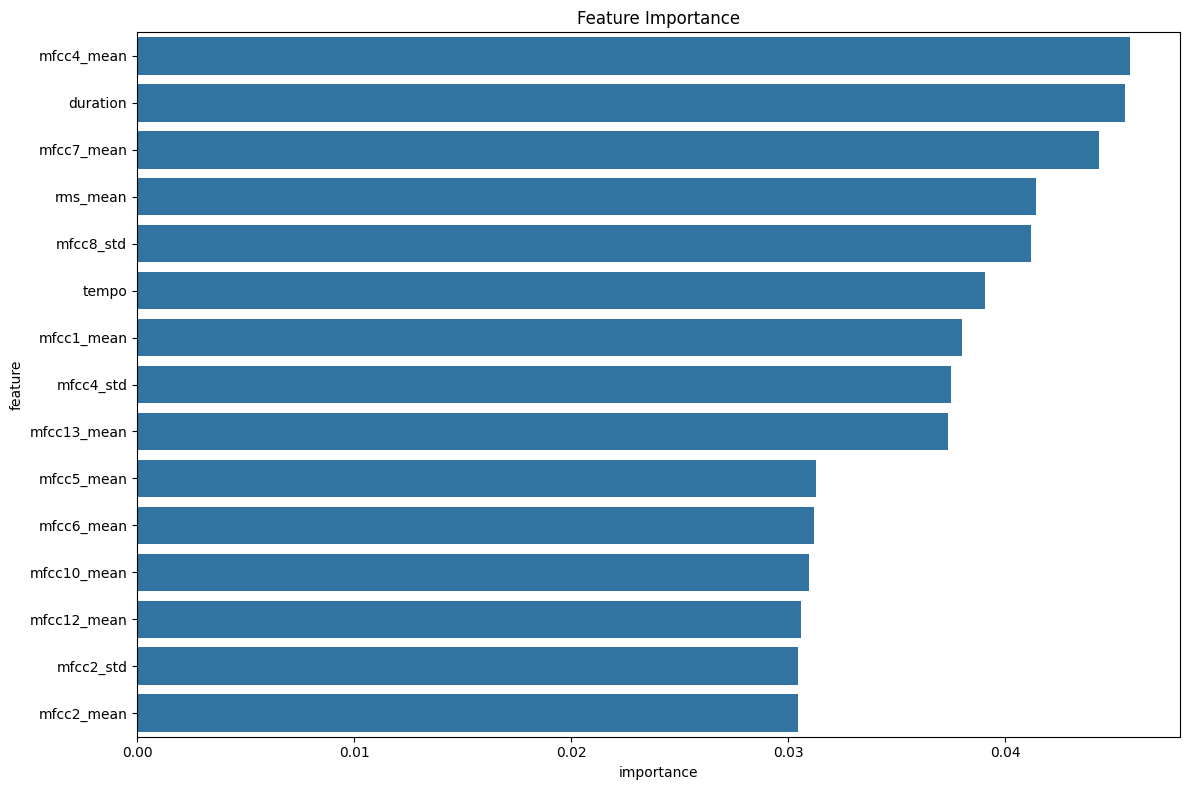


บันทึกโมเดลและ label encoder เรียบร้อยแล้ว


c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Chulin\miniconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from 

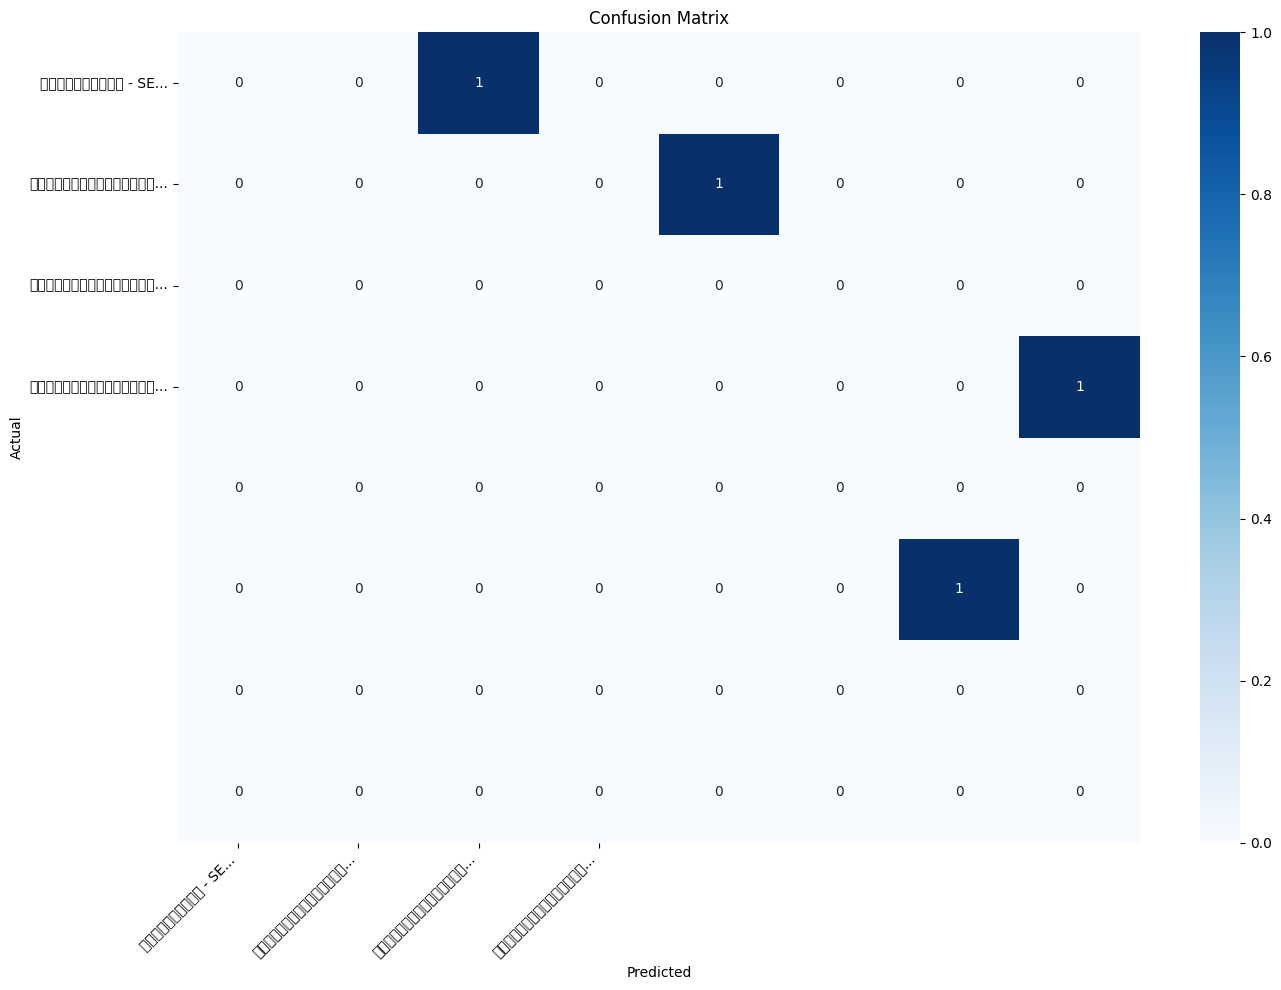

In [13]:
# เทรนโมเดลและประเมินผล
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np

# โหลดฐานข้อมูล
print("กำลังโหลดฐานข้อมูล...")
df_features = pd.read_csv('audio_features.csv')
print(f"มีเพลงทั้งหมด {len(df_features)} เพลง")

# แยก features และ target
X = df_features.drop('filename', axis=1)
y = df_features['filename']

# Encode ชื่อเพลงเป็นตัวเลข
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# แบ่งข้อมูลสำหรับ train และ test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"ข้อมูล training: {X_train.shape[0]} ตัวอย่าง")
print(f"ข้อมูล testing: {X_test.shape[0]} ตัวอย่าง")

# สร้างและเทรนโมเดล
print("\nกำลังเทรนโมเดล Random Forest...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ประเมินผลโมเดล
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)
print(f"ความแม่นยำของโมเดล: {accuracy:.2f}")

# แก้ไขส่วน Cross-validation
# ดูจำนวนตัวอย่างในแต่ละคลาส
from collections import Counter
class_counts = Counter(y_encoded)
min_samples = min(class_counts.values())
print(f"\nจำนวนตัวอย่างในคลาสที่น้อยที่สุด: {min_samples}")

# กำหนดค่า n_splits ให้เหมาะสม
n_splits = min(3, min_samples)
print(f"ใช้ {n_splits}-fold cross-validation")

# Cross-validation ด้วย StratifiedKFold เพื่อรักษาสัดส่วนของคลาส
try:
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X, y_encoded, cv=cv)
    print(f"Cross-validation scores: {cv_scores}")
    print(f"ค่าเฉลี่ย Cross-validation: {cv_scores.mean():.2f} (±{cv_scores.std():.2f})")
except Exception as e:
    print(f"ไม่สามารถทำ cross-validation ได้: {e}")
    print("กำลังลองอีกวิธี...")
    # ถ้ายังไม่สำเร็จ ให้ลองใช้ Leave-One-Out Cross Validation
    from sklearn.model_selection import LeaveOneOut
    loo = LeaveOneOut()
    loo_scores = []
    for train_idx, test_idx in loo.split(X):
        X_train_loo, X_test_loo = X.iloc[train_idx], X.iloc[test_idx]
        y_train_loo, y_test_loo = y_encoded[train_idx], y_encoded[test_idx]
        model_loo = RandomForestClassifier(n_estimators=50, random_state=42)
        model_loo.fit(X_train_loo, y_train_loo)
        loo_scores.append(model_loo.score(X_test_loo, y_test_loo))
    
    print(f"Leave-One-Out CV Score: {np.mean(loo_scores):.2f}")

# แสดงรายงานการจำแนกแบบละเอียด
print("\nรายงานการจำแนกโดยละเอียด:")

# แก้ไขปัญหา target_names ไม่ตรงกับจำนวนคลาส
# หา unique classes ใน y_test และ y_pred
unique_classes_test = np.unique(y_test)
unique_classes_pred = np.unique(y_pred)
unique_classes = np.union1d(unique_classes_test, unique_classes_pred)

# ใช้เฉพาะคลาสที่มีอยู่จริงใน test set
target_names = [le.inverse_transform([class_idx])[0][:30] for class_idx in unique_classes]

# สร้าง classification report
print(classification_report(y_test, y_pred, target_names=target_names))

# ตรวจสอบ feature importance
feature_importances = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeatures ที่สำคัญที่สุด 10 อันดับแรก:")
print(feature_importances.head(10))

# วาดกราฟ feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances.head(15))
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

# บันทึกโมเดลเพื่อนำไปใช้ใน Streamlit
joblib.dump(model, 'song_recognition_model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\nบันทึกโมเดลและ label encoder เรียบร้อยแล้ว")

# สร้าง confusion matrix
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_pred)

# แก้ไขปัญหา labels ไม่ตรงกัน
test_classes = np.unique(y_test)
cm_labels = [le.inverse_transform([idx])[0][:15] + '...' if len(le.inverse_transform([idx])[0]) > 15 else le.inverse_transform([idx])[0] for idx in test_classes]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=cm_labels,
           yticklabels=cm_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
# ฟังก์ชั่นสำหรับ Audio Recognition
import numpy as np
import librosa
import sounddevice as sd
import time
from IPython.display import Audio, display
from scipy.io.wavfile import write
from scipy.spatial.distance import cosine
from sklearn.preprocessing import StandardScaler
import tempfile
import os

# ฟังก์ชันสำหรับบันทึกเสียง
def record_audio(duration=10, fs=22050):
    """บันทึกเสียงจากไมโครโฟน"""
    print(f"กำลังบันทึกเสียง {duration} วินาที...")
    audio = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype='float32')
    
    # แสดง Progress bar ง่ายๆ
    for i in range(10):
        time.sleep(duration/10)
        done = int((i+1) * 10)
        print(f"\rบันทึก: [{'#' * done}{' ' * (100-done)}] {done}%", end='')
    
    sd.wait()  # รอจนกว่าการบันทึกจะเสร็จ
    print("\nบันทึกเสียงเสร็จสิ้น")
    
    return audio.flatten()

# ฟังก์ชันสำหรับสกัด features จากไฟล์เสียง
def extract_features_from_audio(audio, sr=22050):
    """สกัดคุณลักษณะเสียงจากข้อมูลเสียง"""
    features = {}
    
    # Basic properties
    features['duration'] = len(audio) / sr
    
    # Spectral features (mean and std)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc{i+1}_mean'] = np.mean(mfccs[i])
        features[f'mfcc{i+1}_std'] = np.std(mfccs[i])
    
    features['spectral_centroid_mean'] = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr)[0])
    features['spectral_bandwidth_mean'] = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0])
    features['spectral_rolloff_mean'] = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr)[0])
    features['zero_crossing_rate_mean'] = np.mean(librosa.feature.zero_crossing_rate(audio)[0])
    
    # Rhythm features
    tempo, _ = librosa.beat.beat_track(y=audio, sr=sr)
    features['tempo'] = float(tempo)
    
    # Energy
    features['rms_mean'] = np.mean(librosa.feature.rms(y=audio)[0])
    
    return features

# ฟังก์ชันสำหรับค้นหาเพลงที่คล้ายกัน
def find_similar_song(recorded_features, db_features, n_results=5):
    """หาเพลงที่คล้ายที่สุดจากฐานข้อมูล"""
    
    # แปลงคุณลักษณะเสียงให้เป็น DataFrame
    recorded_df = pd.DataFrame([recorded_features])
    
    # เลือกเฉพาะคอลัมน์ที่ต้องการเปรียบเทียบ (ไม่รวมชื่อไฟล์)
    feature_cols = [col for col in db_features.columns if col != 'filename']
    
    # Normalize ข้อมูล
    scaler = StandardScaler()
    db_features_scaled = scaler.fit_transform(db_features[feature_cols])
    recorded_features_scaled = scaler.transform(recorded_df[feature_cols])
    
    # คำนวณความคล้ายคลึง (ระยะห่าง) ระหว่างเสียงที่บันทึกกับทุกเพลงในฐานข้อมูล
    distances = []
    for i, row in enumerate(db_features_scaled):
        # ใช้ cosine distance (1 - cosine similarity)
        dist = cosine(recorded_features_scaled[0], row)
        distances.append((i, dist))
    
    # เรียงลำดับตามความคล้ายคลึง (น้อยไปมาก = คล้ายมากไปคล้ายน้อย)
    distances.sort(key=lambda x: x[1])
    
    # คืนค่าเพลงที่คล้ายที่สุด n_results เพลง
    similar_songs = []
    for i in range(min(n_results, len(distances))):
        idx, dist = distances[i]
        song_name = db_features.iloc[idx]['filename']
        similarity_score = 1 - dist  # แปลงเป็นคะแนนความคล้าย (0-1)
        similar_songs.append((song_name, similarity_score))
    
    return similar_songs

# ฟังก์ชันสำหรับทำนายเพลงด้วยโมเดล ML
def predict_song_with_model(audio, model, le, df_features):
    """ทำนายเพลงโดยใช้โมเดล ML"""
    
    # สกัดคุณลักษณะเสียง
    features = extract_features_from_audio(audio)
    
    # แปลงเป็น DataFrame และเรียงคอลัมน์ให้ตรงกับตอนเทรน
    features_df = pd.DataFrame([features])
    X = features_df[df_features.drop('filename', axis=1).columns]
    
    # ทำนายเพลง
    y_pred = model.predict_proba(X)
    
    # รับค่าความน่าจะเป็นและชื่อเพลงที่เป็นไปได้มากที่สุด 5 อันดับ
    top_indices = np.argsort(y_pred[0])[::-1][:5]
    top_probs = y_pred[0][top_indices]
    top_songs = le.inverse_transform(top_indices)
    
    results = [(song, prob) for song, prob in zip(top_songs, top_probs)]
    return results

โหลดโมเดลที่บันทึกไว้แล้ว

เตรียมพร้อม!
3...
2...
1...
กำลังบันทึกเสียง 10 วินาที...
บันทึก: [####################################################################################################] 100%
บันทึกเสียงเสร็จสิ้น
บันทึกเสียงไว้ที่: C:\Users\Chulin\AppData\Local\Temp\tmpnfdj87g6.wav

เล่นเสียงที่บันทึก:



กำลังวิเคราะห์เสียง...

ผลลัพธ์จากการค้นหาแบบ Similarity Search:
1. เพื่อนดีเด่น (BEST FRIEND 4EVER) - SERIOUS BACON [Official MV].mp3 (ความคล้ายคลึง: 0.6380)
2. เธอ ๆ เพื่อนเราชอบ (Guess Who？) – SERIOUS BACON [Official MV].mp3 (ความคล้ายคลึง: 0.4822)
3. แฟนฉัน (Love Ads) - SERIOUS BACON [Official MV].mp3 (ความคล้ายคลึง: 0.4063)
4. จะกลับไปดีกับเขาก็บอก - SERIOUS BACON [ Official MV ].mp3 (ความคล้ายคลึง: 0.3182)
5. บอกให้ฟังหน่อยนะ (please tell me) - Serious Copter [ Official MV ].mp3 (ความคล้ายคลึง: 0.1594)

ผลลัพธ์จากการทำนายด้วยโมเดล Machine Learning:
1. หากว่าฉัน - SERIOUS BACON [Official MV].mp3 (ความน่าจะเป็น: 0.1800)
2. มีปัญหาปรึกษาดาว - SERIOUS BACON [ Official Audio ].mp3 (ความน่าจะเป็น: 0.1400)
3. เบื้องหลังครั้งแรก! mv #พี่ๆตัดแว่นให้หน่อย สนุกสุดป่วนกวนทั้งกองถ่าย ｜ Serious Bacon.mp3 (ความน่าจะเป็น: 0.1300)
4. อย่าไปรักเขาเลยเธอ (Someone Who Cares) - SERIOUS BACON [Official MV].mp3 (ความน่าจะเป็น: 0.1200)
5. เธอ ๆ เพื่อนเราชอบ (Guess Who？) – SERIOUS BACON [Official MV].mp

C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3494709697.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3494709697.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)
C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3436164481.py:90: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3436164481.py:90: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layou

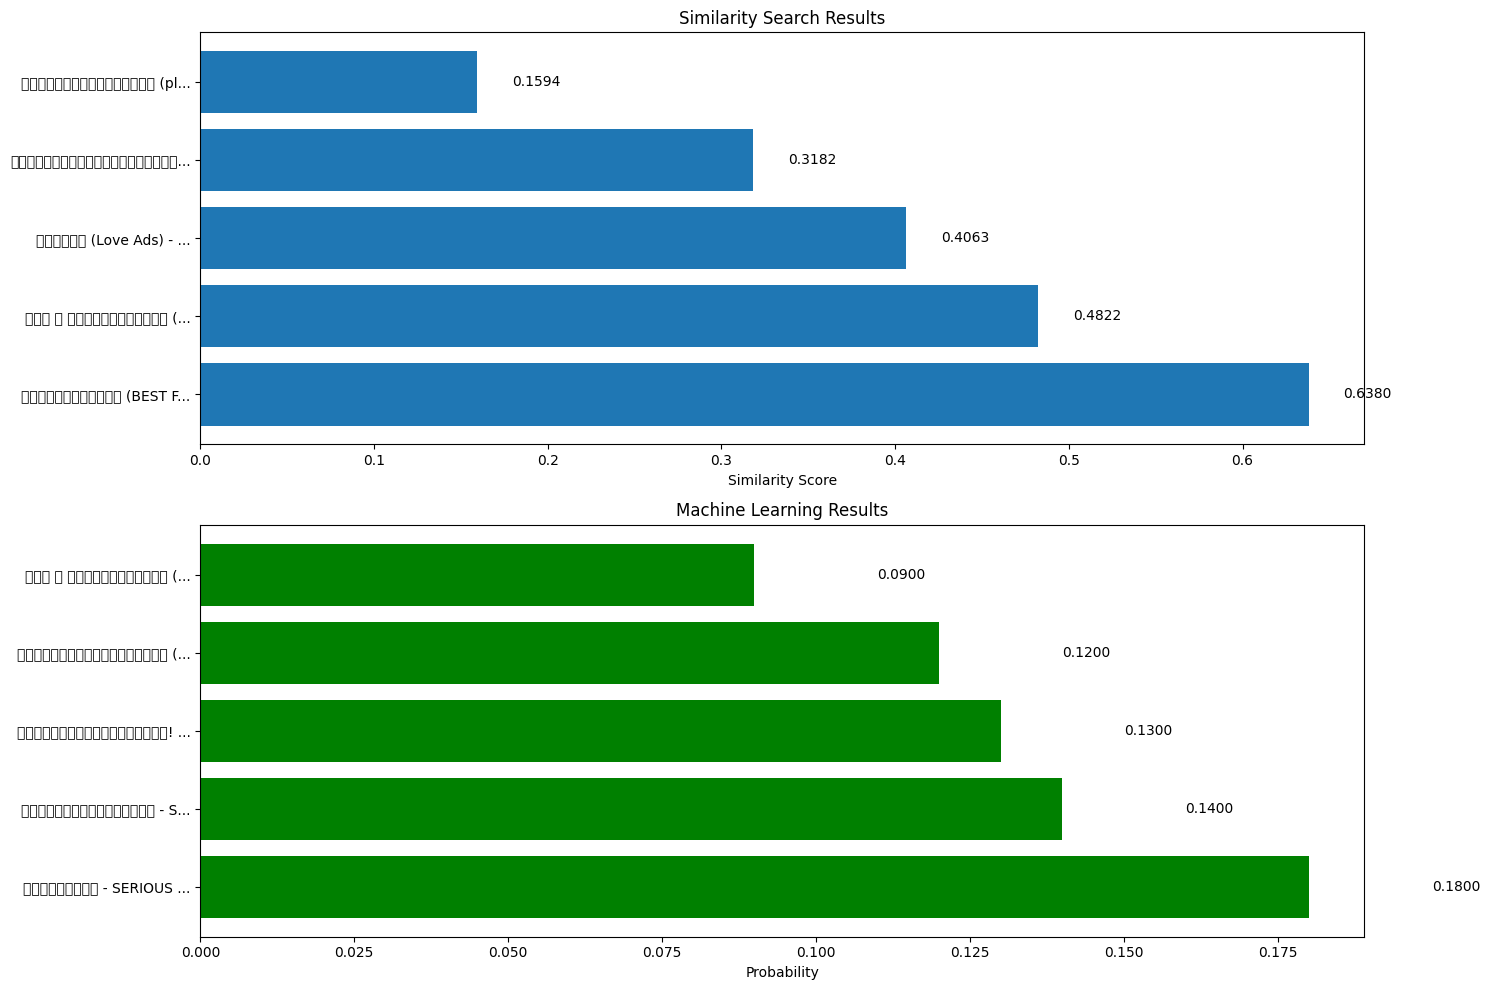

In [25]:
# ทดสอบการบันทึกเสียงและรู้จำเพลง
def test_recognition():
    # โหลดโมเดล (ถ้ามี) หรือใช้โมเดลที่เทรนไว้แล้ว
    try:
        loaded_model = joblib.load('song_recognition_model.pkl')
        loaded_le = joblib.load('label_encoder.pkl')
        print("โหลดโมเดลที่บันทึกไว้แล้ว")
        use_model = loaded_model
        use_le = loaded_le
    except:
        print("ใช้โมเดลที่เพิ่งเทรนเสร็จ")
        use_model = model
        use_le = le
    
    # กำหนดระยะเวลาในการบันทึก
    duration = int(input(f"ระยะเวลาในการบันทึก (วินาที, แนะนำ 5-10): ") or "10")
    
    # นับถอยหลังก่อนบันทึก
    print("\nเตรียมพร้อม!")
    for i in range(3, 0, -1):
        print(f"{i}...")
        time.sleep(1)
    
    # บันทึกเสียง
    audio = record_audio(duration=duration)
    
    # บันทึกเสียงเป็นไฟล์ WAV
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.wav')
    temp_filename = temp_file.name
    write(temp_filename, 22050, np.int16(audio * 32767))
    print(f"บันทึกเสียงไว้ที่: {temp_filename}")
    
    # เล่นเสียงที่บันทึก
    print("\nเล่นเสียงที่บันทึก:")
    display(Audio(audio, rate=22050))
    
    print("\nกำลังวิเคราะห์เสียง...")
    
    # วิเคราะห์เสียงและแสดงผล
    # วิธีที่ 1: ค้นหาเพลงที่คล้ายที่สุด (Similarity Search)
    features = extract_features_from_audio(audio)
    similar_songs = find_similar_song(features, df_features, n_results=5)
    
    print("\nผลลัพธ์จากการค้นหาแบบ Similarity Search:")
    for i, (song, score) in enumerate(similar_songs, 1):
        print(f"{i}. {song} (ความคล้ายคลึง: {score:.4f})")
    
    # วิธีที่ 2: ใช้โมเดล Machine Learning
    ml_results = predict_song_with_model(audio, use_model, use_le, df_features)
    
    print("\nผลลัพธ์จากการทำนายด้วยโมเดล Machine Learning:")
    for i, (song, prob) in enumerate(ml_results, 1):
        print(f"{i}. {song} (ความน่าจะเป็น: {prob:.4f})")
    
    # สร้างกราฟเปรียบเทียบผลลัพธ์
    plt.figure(figsize=(15, 10))
    
    # แสดงผล Similarity Search
    plt.subplot(2, 1, 1)
    similarity_songs = [s[0].split('.')[0][:20] + '...' if len(s[0].split('.')[0]) > 20 else s[0].split('.')[0] for s in similar_songs]
    similarity_scores = [s[1] for s in similar_songs]
    
    y_pos = np.arange(len(similarity_songs))
    bars = plt.barh(y_pos, similarity_scores, align='center')
    plt.yticks(y_pos, similarity_songs)
    plt.xlabel('Similarity Score')
    plt.title('Similarity Search Results')
    
    # เพิ่มค่าคะแนนบนแท่ง
    for bar, score in zip(bars, similarity_scores):
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.4f}', 
                 ha='left', va='center')
    
    # แสดงผล ML
    plt.subplot(2, 1, 2)
    ml_songs = [s[0].split('.')[0][:20] + '...' if len(s[0].split('.')[0]) > 20 else s[0].split('.')[0] for s in ml_results]
    ml_scores = [s[1] for s in ml_results]
    
    y_pos = np.arange(len(ml_songs))
    bars = plt.barh(y_pos, ml_scores, align='center', color='green')
    plt.yticks(y_pos, ml_songs)
    plt.xlabel('Probability')
    plt.title('Machine Learning Results')
    
    # เพิ่มค่าคะแนนบนแท่ง
    for bar, score in zip(bars, ml_scores):
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{score:.4f}', 
                 ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return audio, similar_songs, ml_results

# ทดสอบฟังก์ชั่น (uncomment เพื่อรัน)
audio, similar_songs, ml_results = test_recognition()

In [27]:
# ฟังก์ชั่นรับฟังเสียงต่อเนื่องคล้าย Shazam
def continuous_recognition(timeout=60, threshold=0.1, analysis_duration=5):
    """รับฟังเสียงต่อเนื่องและทำนายเพลงเมื่อตรวจพบเสียงดัง"""
    
    # โหลดโมเดลที่เทรนแล้ว
    try:
        loaded_model = joblib.load('song_recognition_model.pkl')
        loaded_le = joblib.load('label_encoder.pkl')
        print("โหลดโมเดลที่บันทึกไว้แล้ว")
        use_model = loaded_model
        use_le = loaded_le
    except:
        print("ใช้โมเดลที่เพิ่งเทรนเสร็จ")
        use_model = model
        use_le = le
    
    print(f"กำลังรับฟังเสียง... (timeout = {timeout} วินาที, กด Ctrl+C เพื่อหยุด)")
    print(f"ระดับเสียงต้องเกิน {threshold:.2f} เพื่อเริ่มวิเคราะห์")
    
    start_time = time.time()
    last_detection_time = 0
    cooldown = 10  # รอ 10 วินาทีระหว่างการตรวจจับแต่ละครั้ง
    
    try:
        while time.time() - start_time < timeout:
            # บันทึกเสียงสั้นๆ เพื่อตรวจสอบระดับเสียง
            sample = sd.rec(int(1 * 22050), samplerate=22050, channels=1, dtype='float32')
            sd.wait()
            sample = sample.flatten()
            
            # คำนวณความดังของเสียง
            volume = np.abs(sample).mean()
            
            # แสดงระดับเสียง
            level = int(volume * 100)
            print(f"\rระดับเสียง: {'|' * min(level, 50)}{' ' * (50-min(level, 50))} [{level:3d}%]", end="")
            
            current_time = time.time()
            
            # ถ้าเสียงดังเกิน threshold และผ่าน cooldown
            if volume > threshold and (current_time - last_detection_time) > cooldown:
                print("\n\n🎵 ตรวจพบเสียงดัง! กำลังบันทึกและวิเคราะห์...")
                
                # บันทึกเสียงที่ยาวขึ้นเพื่อวิเคราะห์
                audio = record_audio(duration=analysis_duration)
                
                # ทำนายเพลง
                results = predict_song_with_model(audio, use_model, use_le, df_features)
                
                # แสดงผล
                print("\nผลการทำนาย:")
                for i, (song, prob) in enumerate(results[:3], 1):
                    if prob > 0.3:  # แสดงเฉพาะความน่าจะเป็นที่สูงพอ
                        print(f"{i}. {song.split('.')[0]} - {prob:.2f}")
                    else:
                        print(f"{i}. ไม่สามารถระบุเพลงได้แน่ชัด ({prob:.2f})")
                
                # อัปเดตเวลาล่าสุดที่ตรวจพบเสียง
                last_detection_time = current_time
                
                print("\nกำลังรับฟังเสียงต่อ...")
            
            # หน่วงเวลาเล็กน้อย
            time.sleep(0.1)
            
    except KeyboardInterrupt:
        print("\n\nหยุดการทำงานโดยผู้ใช้")
    
    print("\nสิ้นสุดการรับฟัง")

# รัน Shazam-like application (uncomment เพื่อรัน)
continuous_recognition(timeout=120, threshold=0.1, analysis_duration=5)

โหลดโมเดลที่บันทึกไว้แล้ว
กำลังรับฟังเสียง... (timeout = 120 วินาที, กด Ctrl+C เพื่อหยุด)
ระดับเสียงต้องเกิน 0.10 เพื่อเริ่มวิเคราะห์
ระดับเสียง: ||||||||||                                         [ 10%]

🎵 ตรวจพบเสียงดัง! กำลังบันทึกและวิเคราะห์...
กำลังบันทึกเสียง 5 วินาที...
บันทึก: [####################################################################################################] 100%
บันทึกเสียงเสร็จสิ้น

ผลการทำนาย:
1. ไม่สามารถระบุเพลงได้แน่ชัด (0.15)
2. ไม่สามารถระบุเพลงได้แน่ชัด (0.13)
3. ไม่สามารถระบุเพลงได้แน่ชัด (0.12)

กำลังรับฟังเสียงต่อ...


C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3494709697.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


ระดับเสียง: ||||||||||                                         [ 10%]

🎵 ตรวจพบเสียงดัง! กำลังบันทึกและวิเคราะห์...
กำลังบันทึกเสียง 5 วินาที...
บันทึก: [####################################################################################################] 100%
บันทึกเสียงเสร็จสิ้น

ผลการทำนาย:
1. ไม่สามารถระบุเพลงได้แน่ชัด (0.14)
2. ไม่สามารถระบุเพลงได้แน่ชัด (0.14)
3. ไม่สามารถระบุเพลงได้แน่ชัด (0.10)

กำลังรับฟังเสียงต่อ...


C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3494709697.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


ระดับเสียง: |||||||||||||||                                    [ 15%]

🎵 ตรวจพบเสียงดัง! กำลังบันทึกและวิเคราะห์...
กำลังบันทึกเสียง 5 วินาที...
บันทึก: [####################################################################################################] 100%
บันทึกเสียงเสร็จสิ้น

ผลการทำนาย:
1. ไม่สามารถระบุเพลงได้แน่ชัด (0.13)
2. ไม่สามารถระบุเพลงได้แน่ชัด (0.12)
3. ไม่สามารถระบุเพลงได้แน่ชัด (0.11)

กำลังรับฟังเสียงต่อ...


C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3494709697.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


ระดับเสียง: ||||||||||                                         [ 10%]

🎵 ตรวจพบเสียงดัง! กำลังบันทึกและวิเคราะห์...
กำลังบันทึกเสียง 5 วินาที...
บันทึก: [####################################################################################################] 100%
บันทึกเสียงเสร็จสิ้น

ผลการทำนาย:
1. ไม่สามารถระบุเพลงได้แน่ชัด (0.15)
2. ไม่สามารถระบุเพลงได้แน่ชัด (0.14)
3. ไม่สามารถระบุเพลงได้แน่ชัด (0.11)

กำลังรับฟังเสียงต่อ...


C:\Users\Chulin\AppData\Local\Temp\ipykernel_25104\3494709697.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  features['tempo'] = float(tempo)


ระดับเสียง:                                                    [  0%]

หยุดการทำงานโดยผู้ใช้

สิ้นสุดการรับฟัง
